|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>The Naive Loop<h1>|
|<h2>Section:</h2>|<h1>The KV cache<h1>|
|<h2>Lecture:</h2>|<h1><b>Quadratic by accident: what the naive loop really costs<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
# find the repo root. The directory you start from does not matter.
import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cudalib

<module 'cudalib' from '/home/venugopalan/vllm-from-scratch/cudalib/__init__.py'>

# What it costs to forget

A transformer forward pass is a pure function of the whole prefix. Make a
token, append it, then run the whole pass again.

That loop is correct, and nobody writes it twice. Measure it once anyway. The
shape of its cost is the reason the KV cache exists.

In [3]:
model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen3-1.7B', dtype=torch.bfloat16).cuda().eval()
config = model.config


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 311/311 [00:00<00:00, 13148.42it/s]

### Time one forward pass, at several prefix lengths

In [4]:
@torch.inference_mode()
def forward_ms(prefix_len):
  token_ids = torch.randint(0, 1000, (1,prefix_len), device='cuda')
  return cudalib.bench_ms(lambda: model(token_ids, use_cache=False), iters=8, warmup=3, best_of=2)

prefix_lens = np.array([256, 512, 1024, 2048, 4096])
forward_times = np.array([forward_ms(int(prefix_len)) for prefix_len in prefix_lens])

print(f"{'prefix':>7} {'ms':>9} {'ms/token':>10}")
for prefix_len,milliseconds in zip(prefix_lens, forward_times):
  print(f'{prefix_len:>7} {milliseconds:>9.2f} {milliseconds/prefix_len:>10.4f}')

 prefix        ms   ms/token
    256     25.50     0.0996
    512     49.28     0.0963
   1024     94.02     0.0918
   2048    186.17     0.0909
   4096    404.91     0.0989


### Is the cost linear?

The per-token column looks almost flat. At these lengths a straight line fits
it well enough to deceive you.

Do not examine the table. Fit a quadratic and read the coefficient of $L^2$.

In [5]:
quadratic, linear, constant = np.polyfit(prefix_lens, forward_times, 2)
print(f't(L) = {constant:.2f} + {linear:.5f} L + {quadratic:.3e} L^2\n')

for prefix_len in [512, 2048, 4096, 16384]:
  quadratic_ms = quadratic*prefix_len*prefix_len
  share = quadratic_ms / (constant + linear*prefix_len + quadratic_ms)
  print(f'at L={prefix_len:>6}: the L^2 term is {100*share:5.1f}% of the cost')

t(L) = 6.39 + 0.07959 L + 4.311e-06 L^2

at L=   512: the L^2 term is   2.3% of the cost
at L=  2048: the L^2 term is   9.6% of the cost
at L=  4096: the L^2 term is  17.9% of the cost
at L= 16384: the L^2 term is  46.9% of the cost


The quadratic term is present the whole time. It stays too small to see until
the context grows long. This is exactly why the bug reaches production.

# The cost of a whole generation

One forward pass is not what you pay for. Without a cache, $N$ tokens cost the
**sum**:

$$\sum_{L=1}^{N} t(L)$$

A sum over a linear term is already quadratic. So even the flat part of $t(L)$
becomes an $N^2$ bill.

In [6]:
def naive_total(num_tokens):
  prefix_lens_seen = np.arange(1, num_tokens+1)
  return np.sum(constant + linear*prefix_lens_seen
                + quadratic*prefix_lens_seen*prefix_lens_seen)

token_counts = np.array([64,128,256,512,1024,2048,4096])
uncached_totals = np.array([naive_total(int(num_tokens)) for num_tokens in token_counts])

for num_tokens,milliseconds in zip(token_counts, uncached_totals):
  print(f'{num_tokens:>5} tokens: {milliseconds/1000:8.2f} s   ({milliseconds/num_tokens:7.2f} ms per token)')

   64 tokens:     0.57 s   (   8.98 ms per token)
  128 tokens:     1.48 s   (  11.55 ms per token)
  256 tokens:     4.28 s   (  16.71 ms per token)
  512 tokens:    13.92 s   (  27.18 ms per token)
 1024 tokens:    49.85 s   (  48.69 ms per token)
 2048 tokens:   192.42 s   (  93.96 ms per token)
 4096 tokens:   792.74 s   ( 193.54 ms per token)


### Against a cached loop

A cache makes every step a single-token forward pass. Its cost hardly moves
with the context. Measure one step and multiply.

In [7]:
import copy

@torch.inference_mode()
def decode_ms(prefix_len=1024):
  token_ids = torch.randint(0, 1000, (1,prefix_len), device='cuda')
  cache = model(token_ids, use_cache=True).past_key_values
  next_token = torch.randint(0, 1000, (1,1), device='cuda')
  return cudalib.bench_ms(
      lambda: model(next_token, past_key_values=copy.copy(cache), use_cache=True),
      iters=10, warmup=3, best_of=2)

step = decode_ms()
print(f'one cached decode step: {step:.2f} ms, whatever the context')
cached = token_counts * step

one cached decode step: 16.13 ms, whatever the context


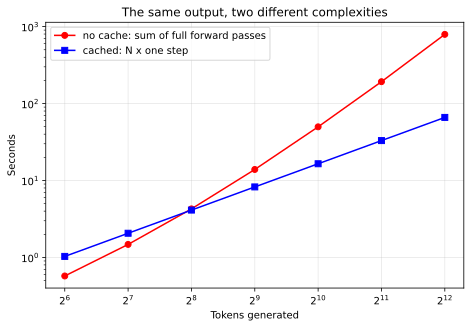

   64 tokens:    0.6x
  128 tokens:    0.7x
  256 tokens:    1.0x
  512 tokens:    1.7x
 1024 tokens:    3.0x
 2048 tokens:    5.8x
 4096 tokens:   12.0x


In [8]:
plt.figure(figsize=(7.5,4.8))
plt.plot(token_counts, uncached_totals/1000, 'ro-', label='no cache: sum of full forward passes')
plt.plot(token_counts, cached/1000, 'bs-', label='cached: N x one step')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Tokens generated')
plt.ylabel('Seconds')
plt.title('The same output, two different complexities')
plt.legend()
plt.grid(alpha=.3)
plt.show()

for num_tokens,uncached_ms,cached_ms in zip(token_counts, uncached_totals, cached):
  print(f'{num_tokens:>5} tokens: {uncached_ms/cached_ms:6.1f}x')

### Read the crossover honestly

At small $N$ the two lines sit close together. The cached line can even lose.
Do not read too much into that corner. The naive line there comes from the
fit, and the fit is least accurate at short prefixes.

The real reason that the lines are close: each step of BOTH loops reads all
3.4 GB of weights. You measured the time of that read in the roofline
section. At a short prefix, the naive pass adds little arithmetic to the read.
So the two loops cost about the same for each token.

The cache still wins, and it wins by more as you make more tokens. The naive
pass grows with the prefix. The cached step stays near one read of the
weights. One side is linear and the other side is not.

The cached step is still a little above one read. Python and the kernel
launches cause part of that gap. Stage 12 removes it.